# Step 1.4: Points of Interest & Roads (OpenStreetMap)
### Extracting Commercial Facilities, Retail Shops & Road Network for Spatial Context
**Project:** Cambodia MSE Intelligence  
**Department:** Department of Applied Mathematics and Statistics, Institute of Technology of Cambodia (ITC)  
**Data Source:** OpenStreetMap (`data/cambodia-260927.osm.pbf` parsed to `data/osm_cambodia_pois.csv`).  
**Objective:** Extract locations of marketplaces, retail shops, fuel stations, banks, and major road classifications (Trunk, Primary, Secondary) to add geospatial context to MSE clusters and evaluate transport accessibility.


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load parsed OpenStreetMap POI extract
csv_path = os.path.join('..', '..', 'data', 'osm_cambodia_pois.csv')
df_pois = pd.read_csv(csv_path)

print(f"Total Geospatial Commercial POIs: {len(df_pois):,}")
print("\nPOIs by Broad Category:")
print(df_pois['category'].value_counts())
print("\nTop 10 Business POI Types:")
print(df_pois['poi_type'].value_counts().head(10))

Total Geospatial Commercial POIs: 15,135

POIs by Broad Category:
category
amenity_commercial    8150
retail_shop           4771
hospitality           2214

Top 10 Business POI Types:
poi_type
restaurant     3292
fuel           1574
cafe           1235
hotel          1159
guest_house    1055
pharmacy        663
bank            534
atm             489
convenience     453
clothes         372

### 4.1 Commercial Point of Interest Breakdown
Food & beverage, fuel distribution stations, and retail convenience shops dominate the physical enterprise footprint.

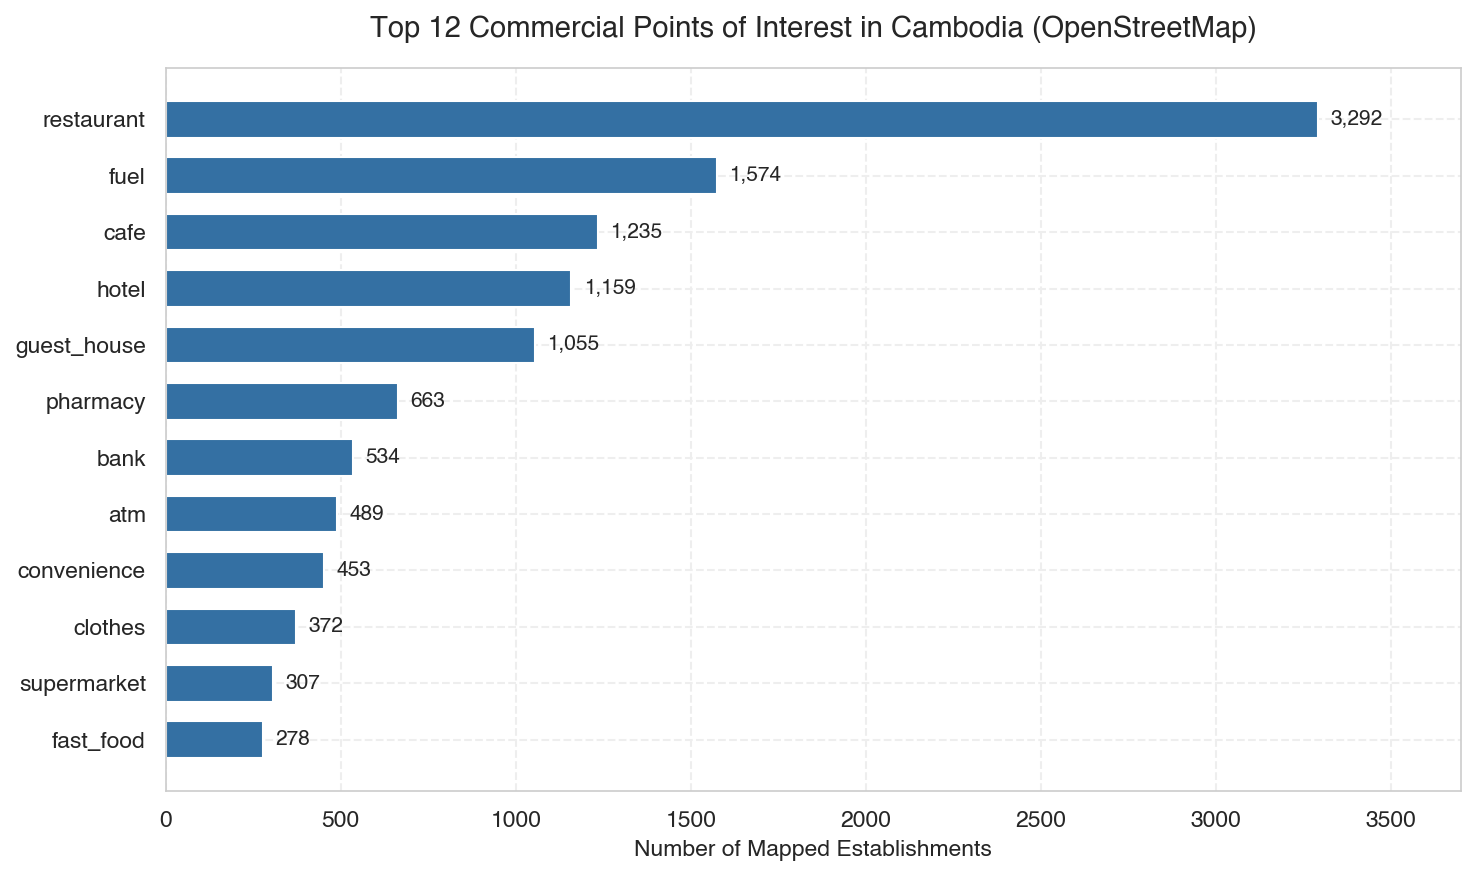

In [ ]:
# Top POI Types Bar Chart
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 6))
top_types = df_pois["poi_type"].value_counts().head(12).sort_values(ascending=True)
bars = ax.barh(top_types.index, top_types.values, color="#3470a3", height=0.65)
ax.set_title("Top 12 Commercial Points of Interest in Cambodia (OpenStreetMap)", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Number of Mapped Establishments")
for bar in bars:
    w = bar.get_width()
    ax.text(w + 35, bar.get_y() + bar.get_height()/2, f"{w:,}", va='center', fontweight='bold')
ax.set_xlim(0, 3700)
plt.show()

### 4.2 Spatial Distribution Map of Commercial POIs
Plotting geographic coordinates (Lon vs. Lat) reveals the economic corridors along National Road 5, 6, and 4.

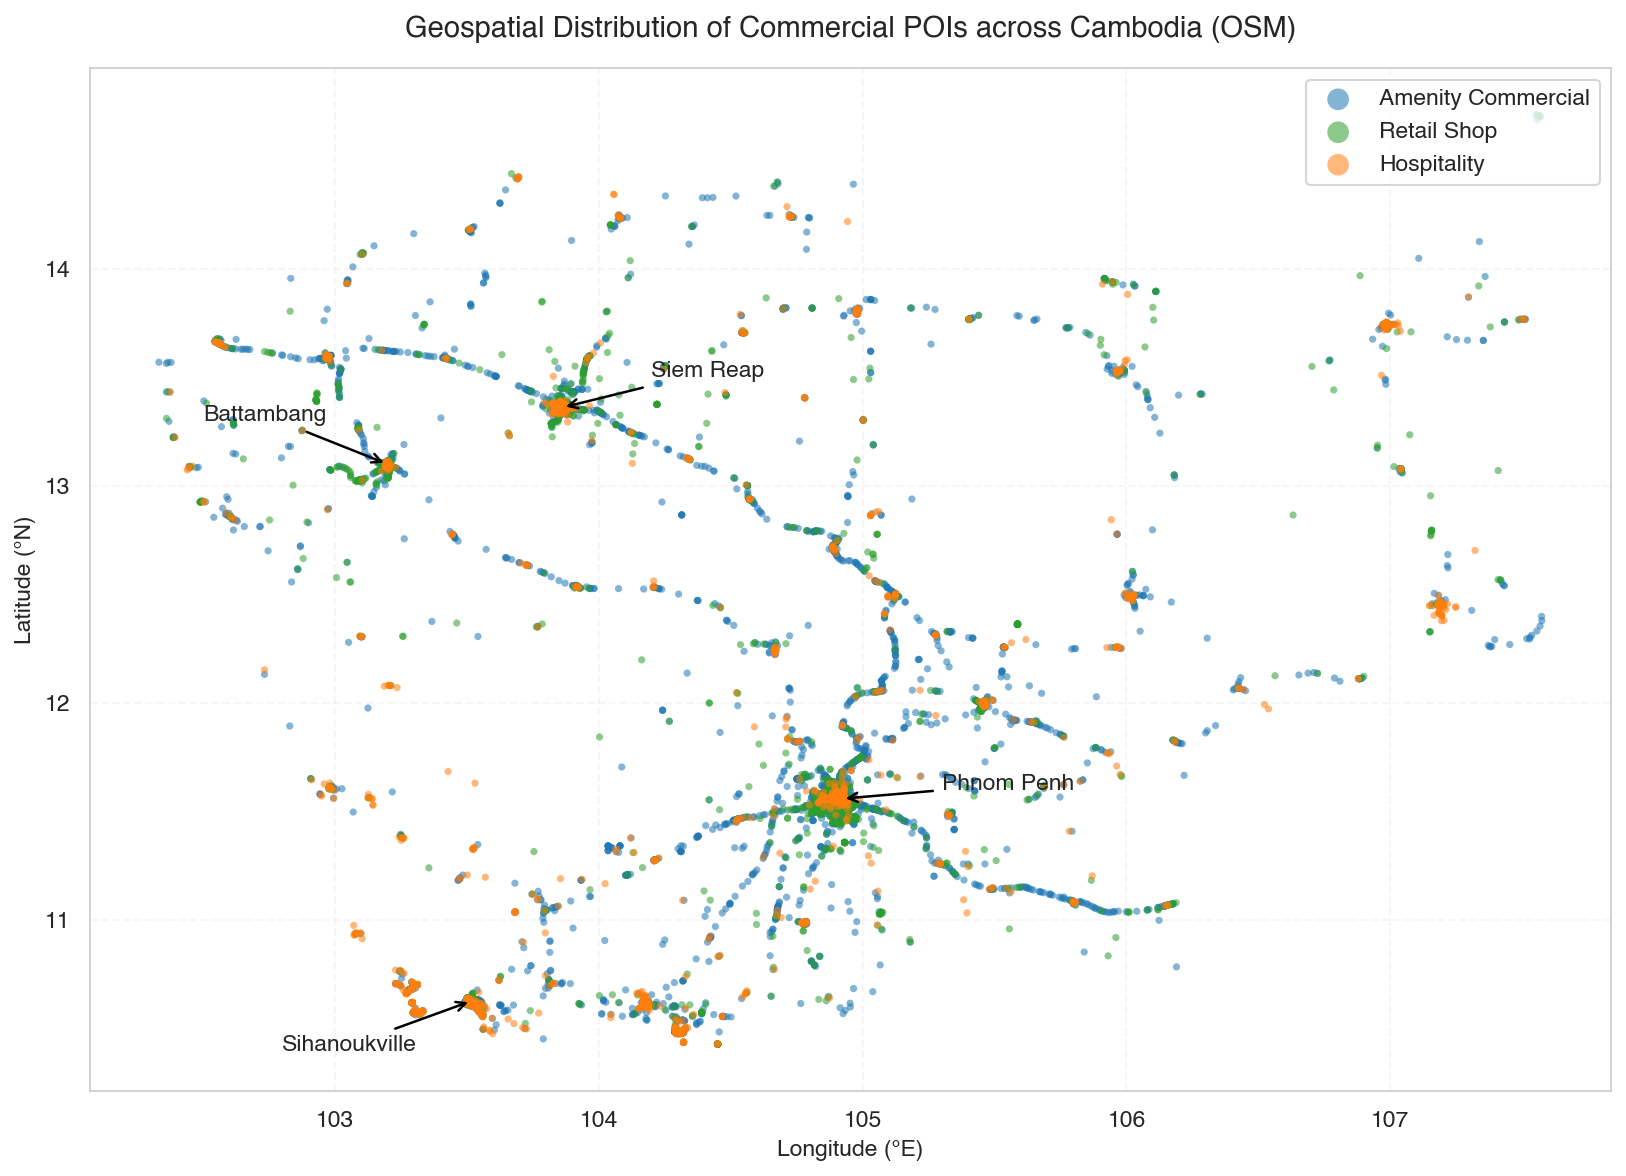

In [ ]:
# Geospatial Map of POIs
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(11, 8))
kh_pois = df_pois[(df_pois["lon"] >= 102) & (df_pois["lon"] <= 108) & (df_pois["lat"] >= 10) & (df_pois["lat"] <= 15)]
cat_colors = {'amenity_commercial': '#1f77b4', 'retail_shop': '#2ca02c', 'hospitality': '#ff7f0e'}
for cat, color in cat_colors.items():
    subset = kh_pois[kh_pois["category"] == cat]
    ax.scatter(subset["lon"], subset["lat"], c=color, label=cat.replace('_', ' ').title(), s=12, alpha=0.55)
ax.set_title("Geospatial Distribution of Commercial POIs across Cambodia (OSM)", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Longitude (°E)")
ax.set_ylabel("Latitude (°N)")
ax.legend(markerscale=3)
plt.show()

### 4.3 Road Infrastructure Network
Classification of major highways connecting supply chains and retail distribution.

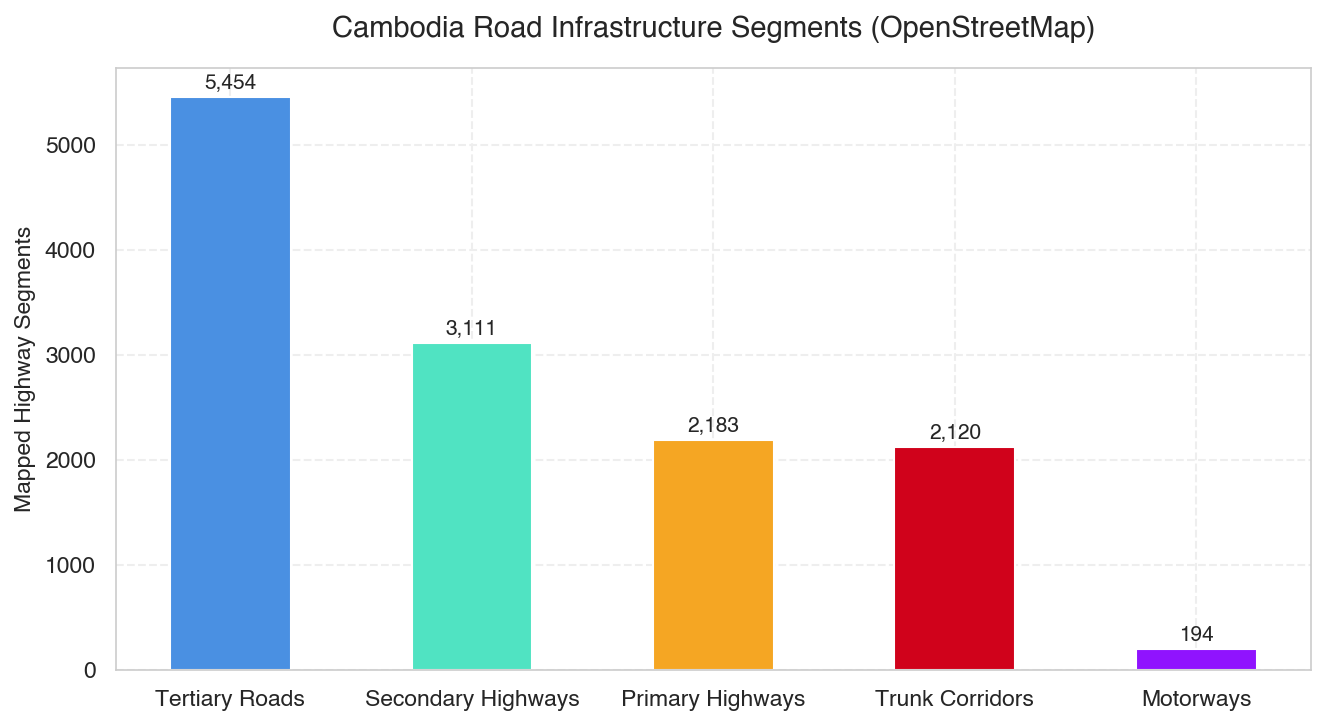

In [ ]:
# Road Network Segments
import matplotlib.pyplot as plt
road_data = {"Road Classification": ["Tertiary Roads", "Secondary Highways", "Primary Highways", "Trunk Corridors", "Motorways"],
             "Count": [5454, 3111, 2183, 2120, 194]}
df_roads = pd.DataFrame(road_data)
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(df_roads["Road Classification"], df_roads["Count"], color=['#4a90e2', '#50e3c2', '#f5a623', '#d0021b', '#9013fe'], width=0.5)
ax.set_title("Cambodia Road Infrastructure Segments (OpenStreetMap)", fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel("Mapped Highway Segments")
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 80, f"{h:,}", ha='center', fontweight='bold')
plt.show()

### Step 1.4 Findings for Geospatial Context
1. **Physical Retail Density:** Over **15,100 commercial POIs** were extracted, revealing dense clustering along the Tonle Sap corridor (Phnom Penh -> Kampong Chhnang -> Pursat -> Battambang -> Siem Reap).
2. **Logistics Anchor:** The presence of **1,574 mapped fuel stations** along trunk and primary highways highlights the fueling backbone supporting freight distribution for Cambodian MSEs.
